In [4]:
!pip install phik -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix
import matplotlib.pyplot as plt

| Название | Описание |
|---|---|
| `AT` | Температура окружающей среды |
| `AP` | Атмосферное давление |
| `AH` | Влажность окружающего воздуха |
| `AFDP` | Перепад давления на воздушном фильтре |
| `GTEP` | Давление выхлопа газовой турбины |
| `TIT` | Температура на входе турбины |
| `TAT` | Температура после турбины |
| `CDP` | Давление на выходе компрессора |
| `TEY` | Выработка энергии турбиной |
| `CO` | Концентрация угарного газа в выбросах |
| `NOx` | Концентрация оксидов азота в выбросах |

## Грузим данные

In [6]:
data_2011 = pd.read_csv('part_2_data/gt_2011.csv')
data_2012 = pd.read_csv('part_2_data/gt_2012.csv')
data_2013 = pd.read_csv('part_2_data/gt_2013.csv')
data_2014 = pd.read_csv('part_2_data/gt_2014.csv')
data_2015 = pd.read_csv('part_2_data/gt_2015.csv')

In [7]:
datasets = [data_2011, data_2012, data_2013, data_2014, data_2015]

In [8]:
data_2011.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7411 entries, 0 to 7410
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7411 non-null   float64
 1   AP      7411 non-null   float64
 2   AH      7411 non-null   float64
 3   AFDP    7411 non-null   float64
 4   GTEP    7411 non-null   float64
 5   TIT     7411 non-null   float64
 6   TAT     7411 non-null   float64
 7   TEY     7411 non-null   float64
 8   CDP     7411 non-null   float64
 9   CO      7411 non-null   float64
 10  NOX     7411 non-null   float64
dtypes: float64(11)
memory usage: 637.0 KB


In [9]:
data_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7628 entries, 0 to 7627
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7628 non-null   float64
 1   AP      7628 non-null   float64
 2   AH      7628 non-null   float64
 3   AFDP    7628 non-null   float64
 4   GTEP    7628 non-null   float64
 5   TIT     7628 non-null   float64
 6   TAT     7628 non-null   float64
 7   TEY     7628 non-null   float64
 8   CDP     7628 non-null   float64
 9   CO      7628 non-null   float64
 10  NOX     7628 non-null   float64
dtypes: float64(11)
memory usage: 655.7 KB


In [10]:
data_2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7152 entries, 0 to 7151
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7152 non-null   float64
 1   AP      7152 non-null   float64
 2   AH      7152 non-null   float64
 3   AFDP    7152 non-null   float64
 4   GTEP    7152 non-null   float64
 5   TIT     7152 non-null   float64
 6   TAT     7152 non-null   float64
 7   TEY     7152 non-null   float64
 8   CDP     7152 non-null   float64
 9   CO      7152 non-null   float64
 10  NOX     7152 non-null   float64
dtypes: float64(11)
memory usage: 614.8 KB


In [11]:
data_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7158 entries, 0 to 7157
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7158 non-null   float64
 1   AP      7158 non-null   float64
 2   AH      7158 non-null   float64
 3   AFDP    7158 non-null   float64
 4   GTEP    7158 non-null   float64
 5   TIT     7158 non-null   float64
 6   TAT     7158 non-null   float64
 7   TEY     7158 non-null   float64
 8   CDP     7158 non-null   float64
 9   CO      7158 non-null   float64
 10  NOX     7158 non-null   float64
dtypes: float64(11)
memory usage: 615.3 KB


In [12]:
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7384 entries, 0 to 7383
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7384 non-null   float64
 1   AP      7384 non-null   float64
 2   AH      7384 non-null   float64
 3   AFDP    7384 non-null   float64
 4   GTEP    7384 non-null   float64
 5   TIT     7384 non-null   float64
 6   TAT     7384 non-null   float64
 7   TEY     7384 non-null   float64
 8   CDP     7384 non-null   float64
 9   CO      7384 non-null   float64
 10  NOX     7384 non-null   float64
dtypes: float64(11)
memory usage: 634.7 KB


In [13]:
new_datasets = []

In [14]:
# Соединим датасеты
for year, dataset in zip(range(2011, 2016), datasets):
    dataset['year'] = year
    new_datasets.append(dataset)

data = pd.concat(new_datasets, ignore_index=True)
data.info()
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36733 entries, 0 to 36732
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      36733 non-null  float64
 1   AP      36733 non-null  float64
 2   AH      36733 non-null  float64
 3   AFDP    36733 non-null  float64
 4   GTEP    36733 non-null  float64
 5   TIT     36733 non-null  float64
 6   TAT     36733 non-null  float64
 7   TEY     36733 non-null  float64
 8   CDP     36733 non-null  float64
 9   CO      36733 non-null  float64
 10  NOX     36733 non-null  float64
 11  year    36733 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 3.4 MB


In [15]:
data.to_csv('combined_data.csv', index=False)

## EDA

| Название | Описание |
|---|---|
| `AT` | Температура окружающей среды |
| `AP` | Атмосферное давление |
| `AH` | Влажность окружающего воздуха |
| `AFDP` | Перепад давления на воздушном фильтре |
| `GTEP` | Давление выхлопа газовой турбины |
| `TIT` | Температура на входе турбины |
| `TAT` | Температура после турбины |
| `CDP` | Давление на выходе компрессора |
| `TEY` | Выработка энергии турбиной |
| `CO` | Концентрация угарного газа в выбросах |
| `NOx` | Концентрация оксидов азота в выбросах |

***Данные представляют собой почасовые агрегированные измерения газовой турбины и отсортированы в хронологическом порядке***

In [16]:
data = pd.read_csv('combined_data.csv')
data.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952,2011
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377,2011
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776,2011
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505,2011
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028,2011


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36733 entries, 0 to 36732
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      36733 non-null  float64
 1   AP      36733 non-null  float64
 2   AH      36733 non-null  float64
 3   AFDP    36733 non-null  float64
 4   GTEP    36733 non-null  float64
 5   TIT     36733 non-null  float64
 6   TAT     36733 non-null  float64
 7   TEY     36733 non-null  float64
 8   CDP     36733 non-null  float64
 9   CO      36733 non-null  float64
 10  NOX     36733 non-null  float64
 11  year    36733 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 3.4 MB


In [18]:
data.isna().sum()

AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
year    0
dtype: int64

In [19]:
data.duplicated().sum()

np.int64(7)

Посмотрим на дубликаты

In [20]:
data[data.duplicated(keep=False)]

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
26398,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26399,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26400,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26401,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26402,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
27388,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27389,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27390,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27391,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014


Заметим, что полные дубликаты у нас есть только в 2014 году

Также видно, что записи о наблюдениях идут друг за другом по индексам, а значит скорее всего это ошибка - поэтому удалим дубликаты

In [21]:
data.drop_duplicates(inplace=True)

In [22]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,36726.0,17.711451,7.447561,-6.234800,11.779250,17.79800,23.66400,37.1030
AP,36726.0,1013.071521,6.463155,985.850000,1008.800000,1012.60000,1017.00000,1036.6000
AH,36726.0,77.864274,14.461250,24.085000,68.182500,80.46550,89.37375,100.2000
AFDP,36726.0,3.925410,0.773939,2.087400,3.355525,3.93745,4.37680,7.6106
GTEP,36726.0,25.563537,4.196157,17.698000,23.127250,25.10450,29.05900,40.7160
TIT,36726.0,1081.427166,17.537244,1000.800000,1071.800000,1085.90000,1097.00000,1100.9000
TAT,36726.0,546.158062,6.842901,511.040000,544.720000,549.88000,550.04000,550.6100
TEY,36726.0,133.506079,15.619558,100.020000,124.450000,133.73000,144.08000,179.5000
CDP,36726.0,12.060470,1.088861,9.851800,11.434000,11.96500,12.85375,15.1590
CO,36726.0,2.372627,2.262856,0.000388,1.182325,1.71370,2.84335,44.1030


Тут сложно что то сказать - видно только что данные имеют разный масштаб

In [23]:
data.shape

(36726, 12)

In [24]:
cols = data.drop(columns=['year']).columns.tolist()
print(cols)

['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']


### Смотрим распредеения

------------ Описание AT ---------------


count    36726.000000
mean        17.711451
std          7.447561
min         -6.234800
25%         11.779250
50%         17.798000
75%         23.664000
max         37.103000
Name: AT, dtype: float64

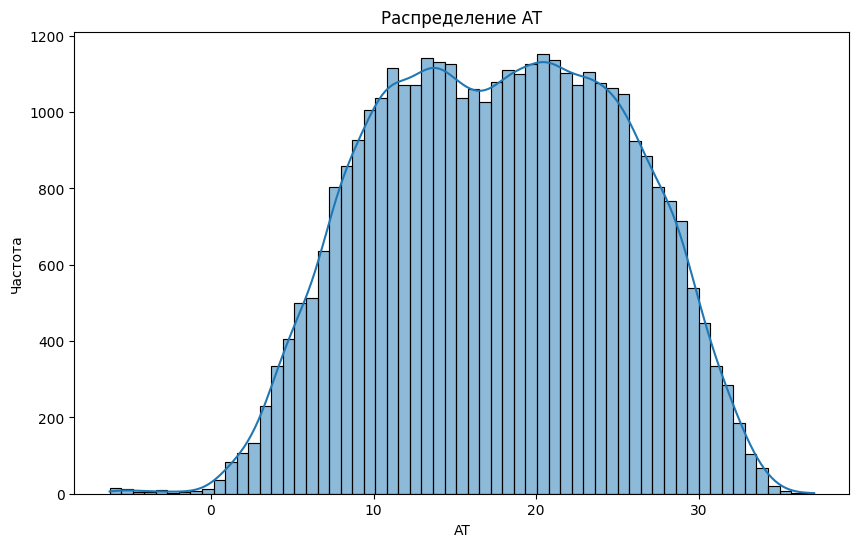

------
------------ Описание AP ---------------


count    36726.000000
mean      1013.071521
std          6.463155
min        985.850000
25%       1008.800000
50%       1012.600000
75%       1017.000000
max       1036.600000
Name: AP, dtype: float64

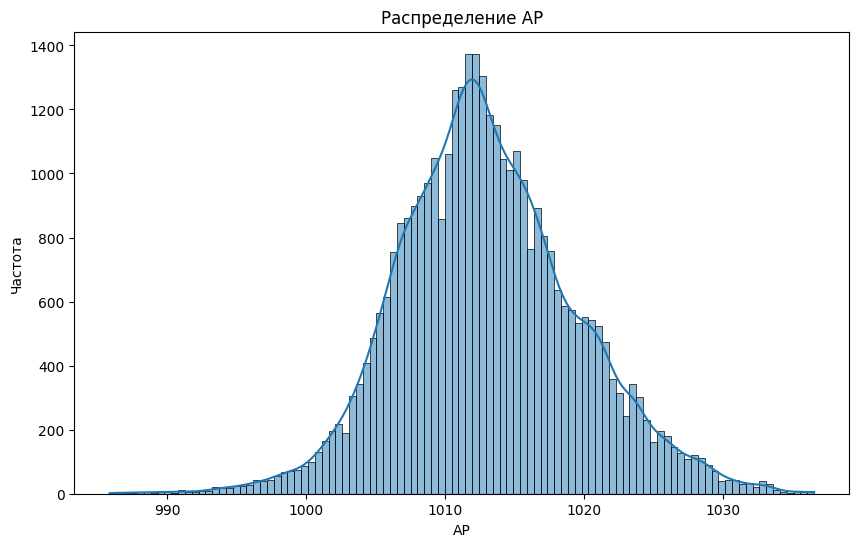

------
------------ Описание AH ---------------


count    36726.000000
mean        77.864274
std         14.461250
min         24.085000
25%         68.182500
50%         80.465500
75%         89.373750
max        100.200000
Name: AH, dtype: float64

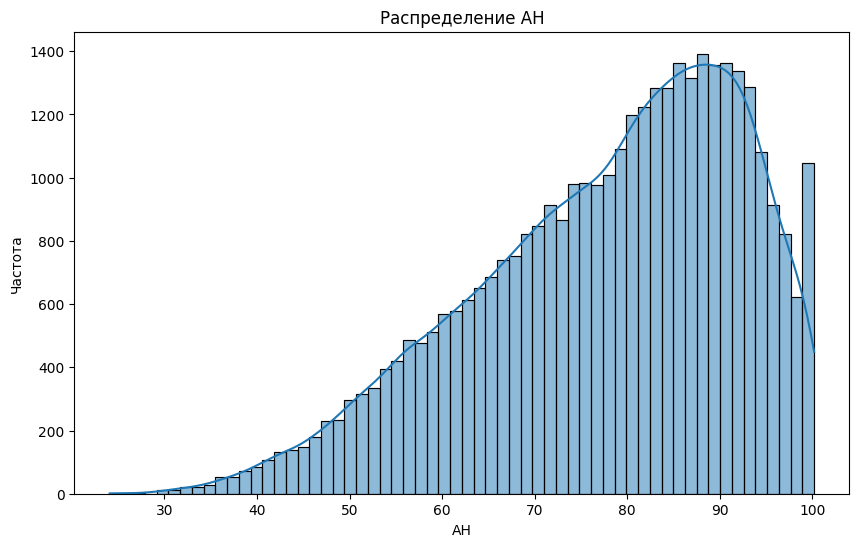

------
------------ Описание AFDP ---------------


count    36726.000000
mean         3.925410
std          0.773939
min          2.087400
25%          3.355525
50%          3.937450
75%          4.376800
max          7.610600
Name: AFDP, dtype: float64

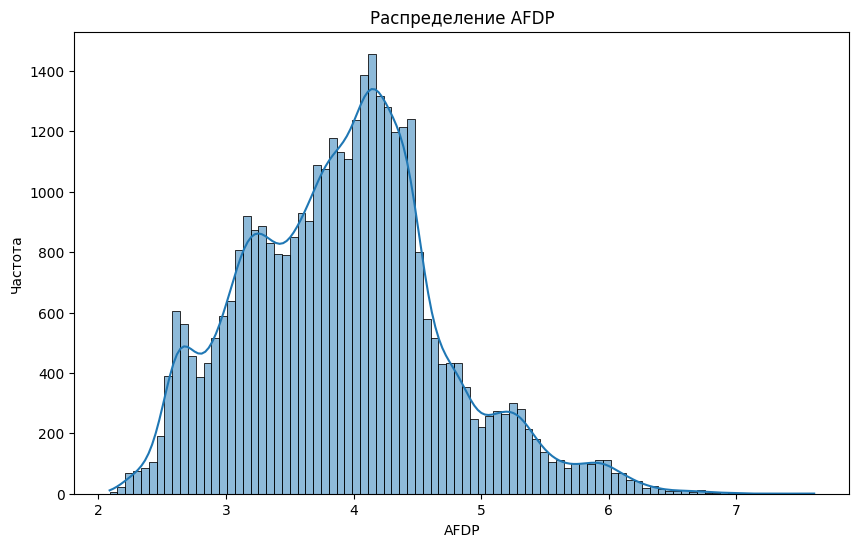

------
------------ Описание GTEP ---------------


count    36726.000000
mean        25.563537
std          4.196157
min         17.698000
25%         23.127250
50%         25.104500
75%         29.059000
max         40.716000
Name: GTEP, dtype: float64

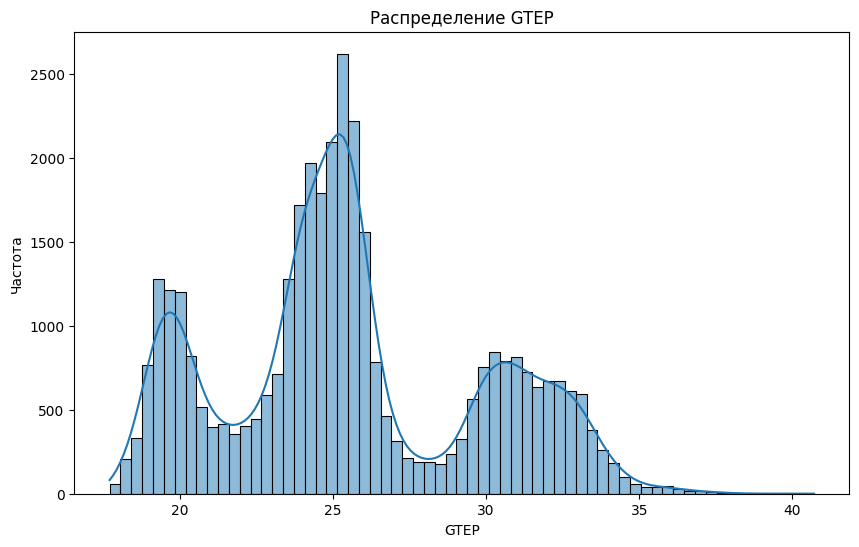

------
------------ Описание TIT ---------------


count    36726.000000
mean      1081.427166
std         17.537244
min       1000.800000
25%       1071.800000
50%       1085.900000
75%       1097.000000
max       1100.900000
Name: TIT, dtype: float64

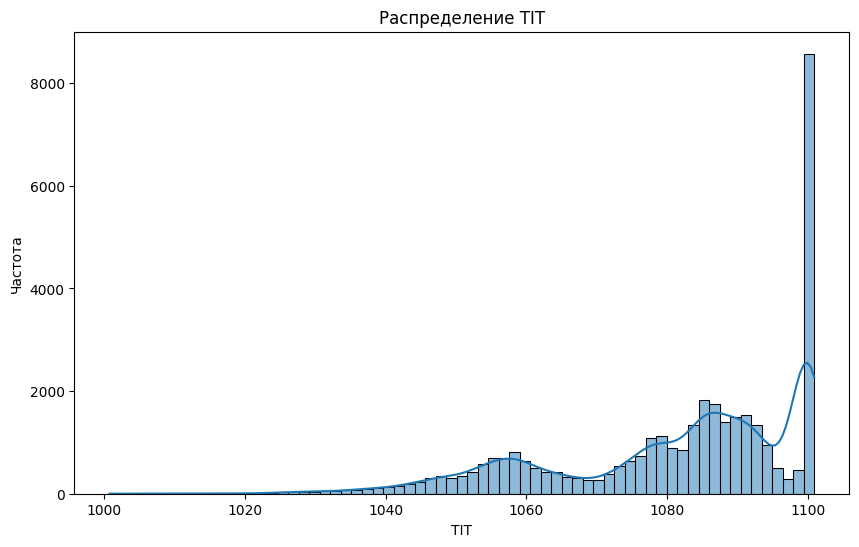

------
------------ Описание TAT ---------------


count    36726.000000
mean       546.158062
std          6.842901
min        511.040000
25%        544.720000
50%        549.880000
75%        550.040000
max        550.610000
Name: TAT, dtype: float64

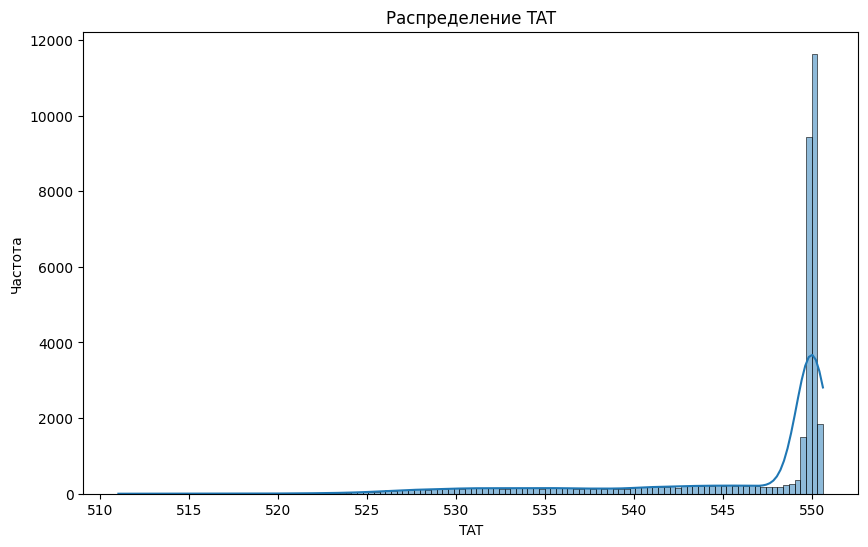

------
------------ Описание TEY ---------------


count    36726.000000
mean       133.506079
std         15.619558
min        100.020000
25%        124.450000
50%        133.730000
75%        144.080000
max        179.500000
Name: TEY, dtype: float64

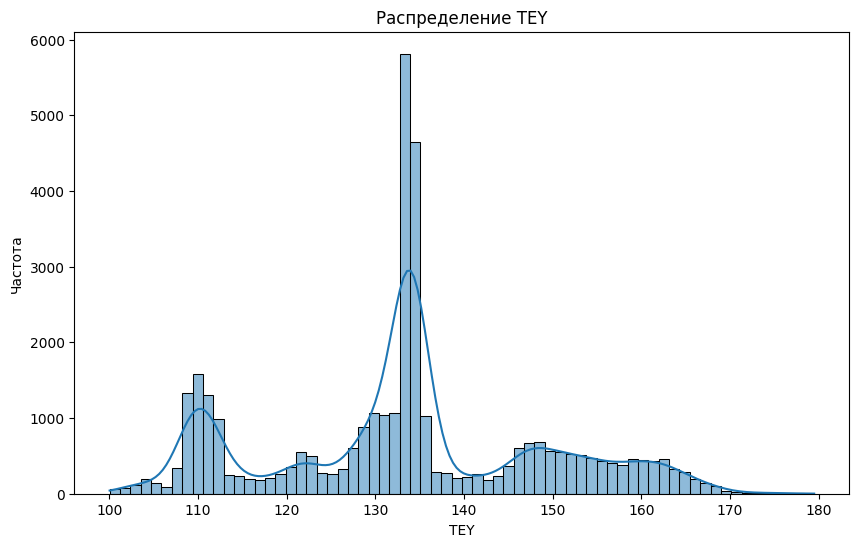

------
------------ Описание CDP ---------------


count    36726.000000
mean        12.060470
std          1.088861
min          9.851800
25%         11.434000
50%         11.965000
75%         12.853750
max         15.159000
Name: CDP, dtype: float64

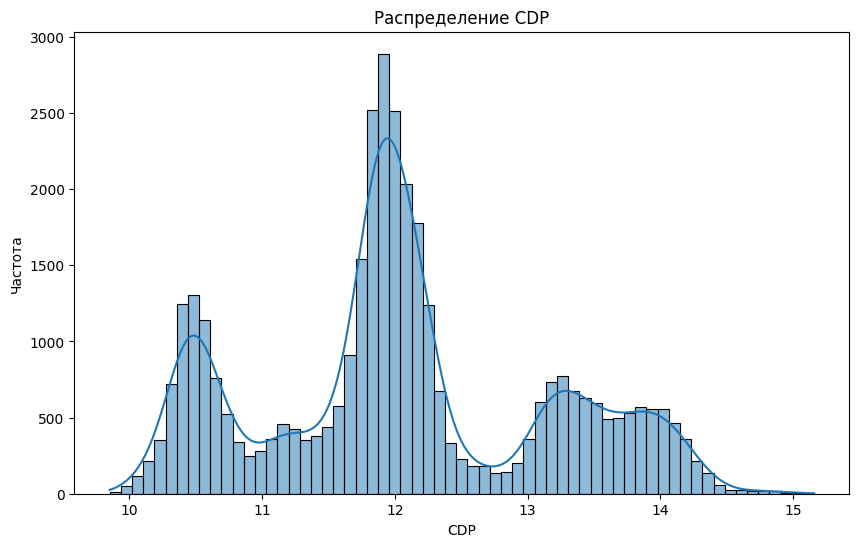

------
------------ Описание CO ---------------


count    36726.000000
mean         2.372627
std          2.262856
min          0.000388
25%          1.182325
50%          1.713700
75%          2.843350
max         44.103000
Name: CO, dtype: float64

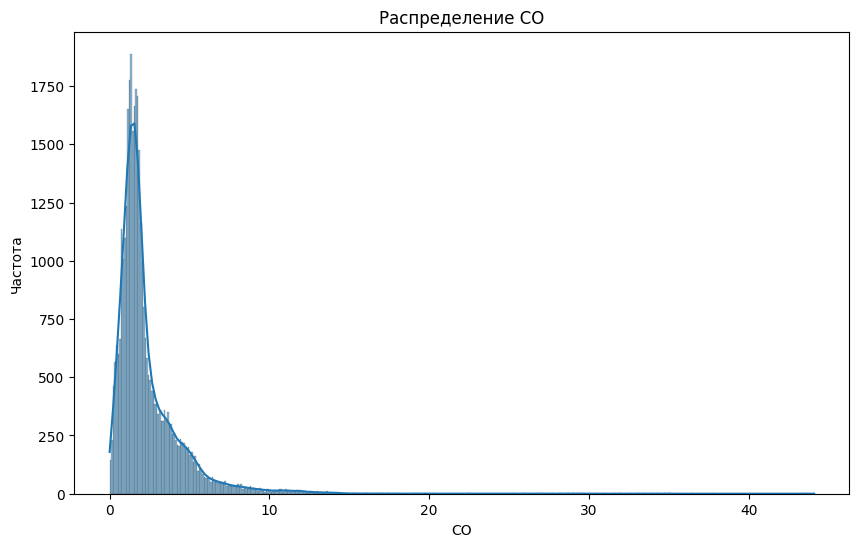

------
------------ Описание NOX ---------------


count    36726.000000
mean        65.296061
std         11.677402
min         25.905000
25%         57.164250
50%         63.851000
75%         71.549000
max        119.910000
Name: NOX, dtype: float64

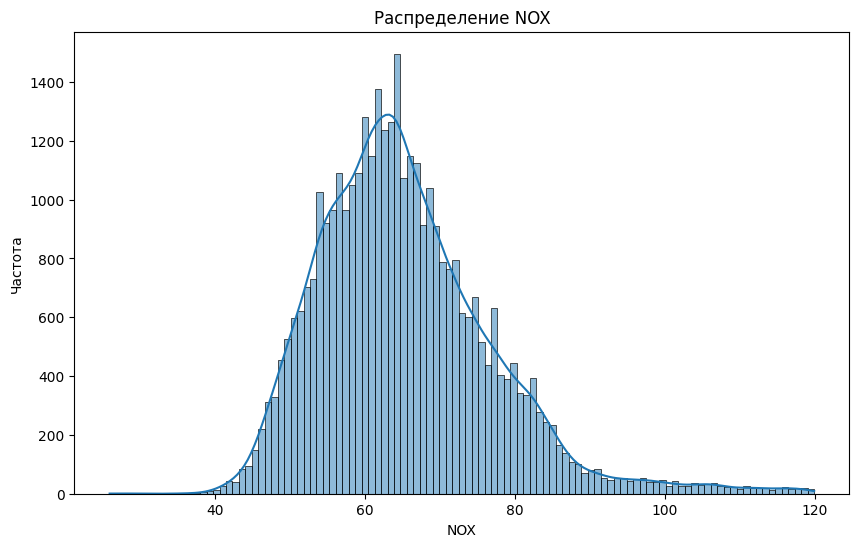

------


In [25]:
for col in cols:

    print(f'------------ Описание {col} ---------------')
    display(data[col].describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()  

    print(f'------')

* АТ (температура) - температура преимущественно теплая или жаркая т.к данные собирались в Турции
* AP (атмосферное давление) - распределение близко к нормальному, явных сильных выбросов не видно
* AH (Влажность воздуха) - большая часть наблюдений сосредоточена в области высоких значений влажности, вероятно это тоже связано с тем. что турбина в Турции
* AFDP (перепад давления на воздушном фильтре) - похоже. что у этого признака есть несколько пиков, вероятно это связано с особенностями работы турбины, распределение смещено влево
* GTEP (давление выхлопа газовой турбины) - заметно, что у признака явно несколько пиков, вероятно у турбины может быть несколько режимов работы
* TIT (температура на входе турбины) - начения сильно смещены к верхней границе диапазона, скорее всего у турбины есть определенная рабочая температура, а более низкие указывают либо на какой нибудь разгон или более слабые режимы работы
* TAT (температура после турбины) - признак сильно сконцентрирован около верхней границы диапазона, скорее всего температура после турбины поддерживается на определенном рабочем уровне
* TEY (выработка энергии турбиной) - заметно несколько пиков, особенно заметен пик где-то на уровне 135
* CDP (давление на выходе компрессора) - тоже имеет несколько пиков
* CO (выбросы угарного газа) - признак сильно смещен влево, но есть длинный правый хвост, которые говорят о пвышенных выбросах
* NOX (выбросы оксидов азота) - признак немного смещен влево, но больше похож на нормальное распределение, но заметен правый хвост

По распределениям можно сказать, что скорее всего у турбины несколько режимов работы, которые влияют на показатели

### Смотрим корреляции

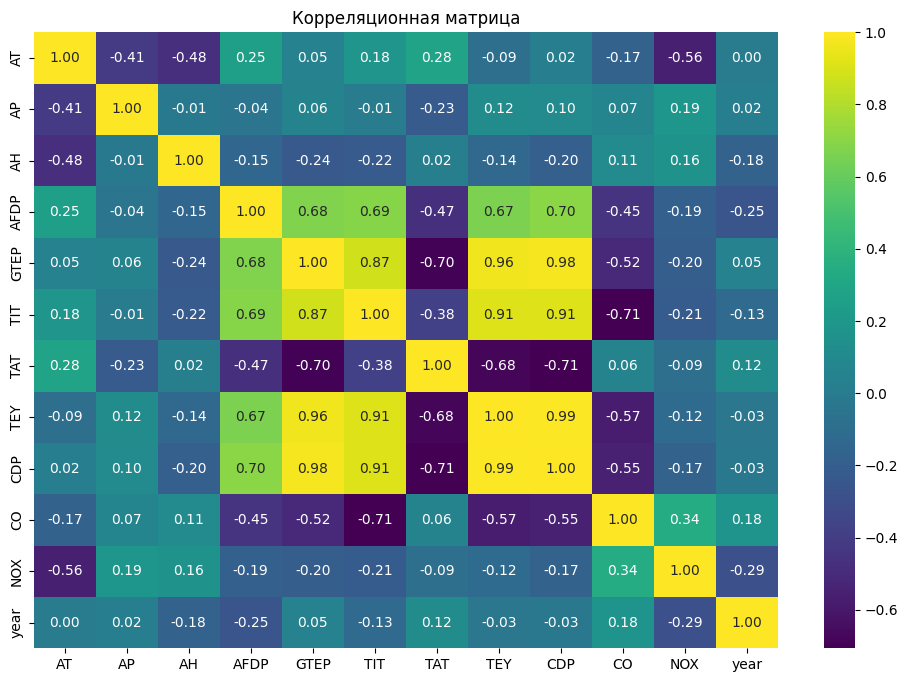

In [26]:
corr = data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis')
plt.title('Корреляционная матрица')
plt.show()

In [27]:
phik_corr = data.phik_matrix()
phik_corr

interval columns not set, guessing: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX', 'year']


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
AT,1.000000,0.605885,0.609886,0.461780,0.593510,0.426365,0.516504,0.725475,0.688464,0.217837,0.586036,0.218611
AP,0.605885,1.000000,0.207972,0.221531,0.372873,0.220338,0.354038,0.463158,0.462787,0.149011,0.315661,0.239394
AH,0.609886,0.207972,1.000000,0.250385,0.368250,0.336827,0.188997,0.294495,0.368209,0.153260,0.203627,0.401832
AFDP,0.461780,0.221531,0.250385,1.000000,0.692228,0.702931,0.572548,0.679708,0.721555,0.501273,0.408752,0.458429
GTEP,0.593510,0.372873,0.368250,0.692228,1.000000,0.858523,0.846986,0.931719,0.957363,0.599318,0.524949,0.384961
TIT,0.426365,0.220338,0.336827,0.702931,0.858523,1.000000,0.707422,0.912940,0.905682,0.783491,0.613266,0.516718
TAT,0.516504,0.354038,0.188997,0.572548,0.846986,0.707422,1.000000,0.880816,0.907682,0.313590,0.362977,0.316750
TEY,0.725475,0.463158,0.294495,0.679708,0.931719,0.912940,0.880816,1.000000,0.976626,0.619478,0.517368,0.520809
CDP,0.688464,0.462787,0.368209,0.721555,0.957363,0.905682,0.907682,0.976626,1.000000,0.608698,0.498906,0.414766
CO,0.217837,0.149011,0.153260,0.501273,0.599318,0.783491,0.313590,0.619478,0.608698,1.000000,0.591118,0.219231


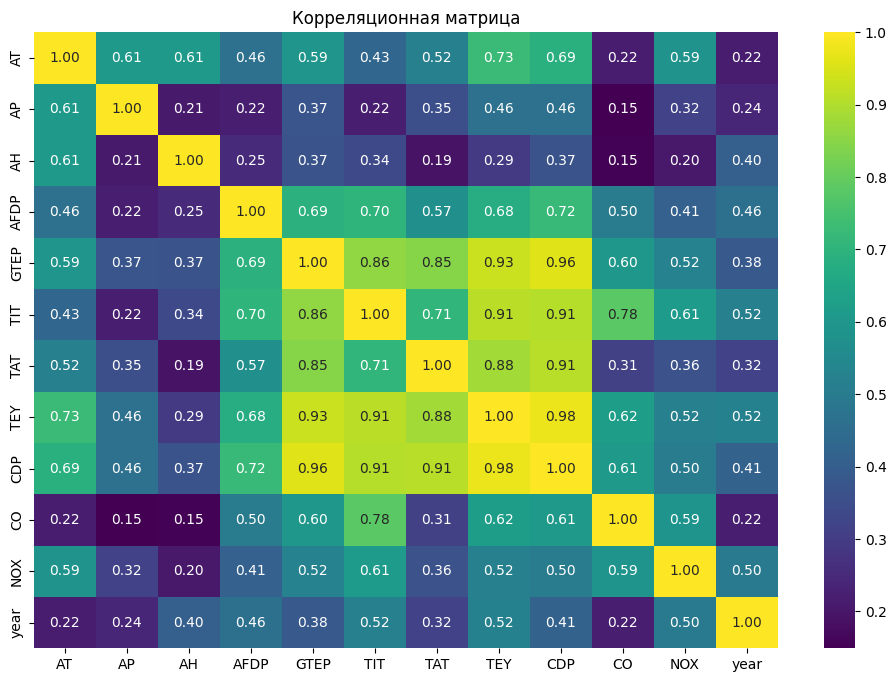

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(phik_corr, annot=True, fmt='.2f', cmap='viridis')
plt.title('Корреляционная матрица')
plt.show()

------------ Описание NOX ---------------


count    36726.000000
mean        65.296061
std         11.677402
min         25.905000
25%         57.164250
50%         63.851000
75%         71.549000
max        119.910000
Name: NOX, dtype: float64

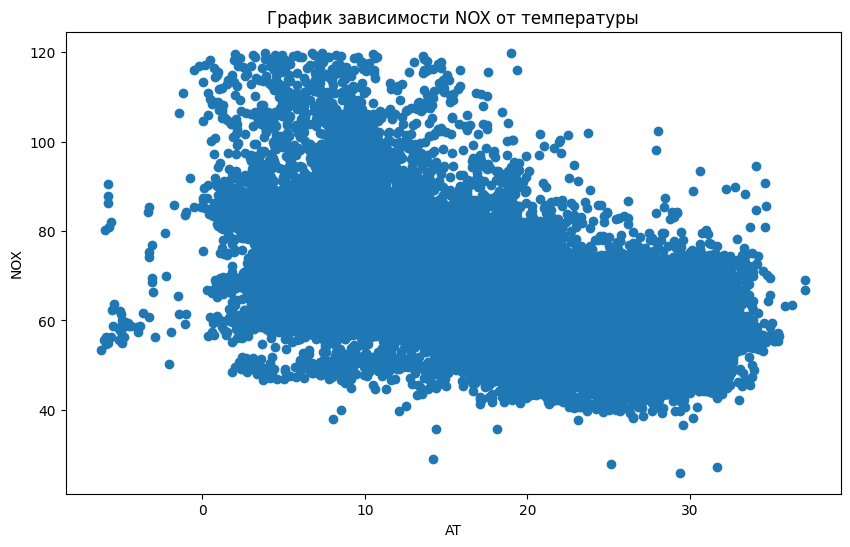

------
------------ Описание CO ---------------


count    36726.000000
mean         2.372627
std          2.262856
min          0.000388
25%          1.182325
50%          1.713700
75%          2.843350
max         44.103000
Name: CO, dtype: float64

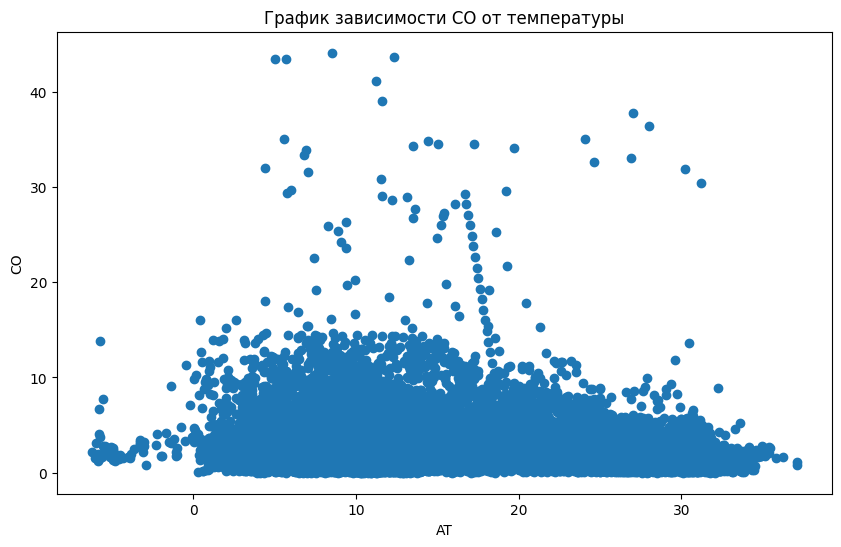

------


In [49]:
for col in ['NOX', 'CO']:

    print(f'------------ Описание {col} ---------------')
    display(data[col].describe())

    plt.figure(figsize=(10, 6))
    plt.scatter(data['AT'], data[col])
    plt.title(f'График зависимости {col} от температуры')
    plt.xlabel('AT')
    plt.ylabel(col)
    plt.show()  

    print(f'------')


### Возможно, стоит выделить за гипотезу тот факт, что изменение температуры окружающей среды влияет на объем выбросов CO и NOX

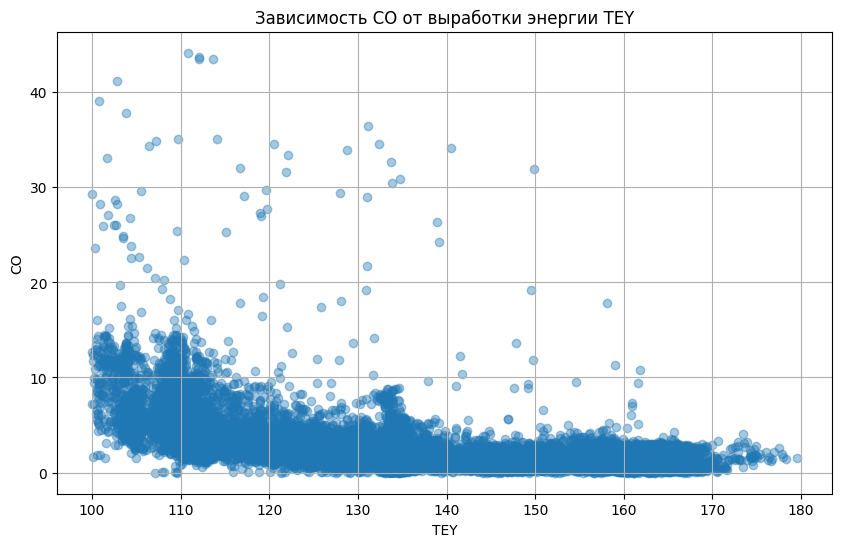

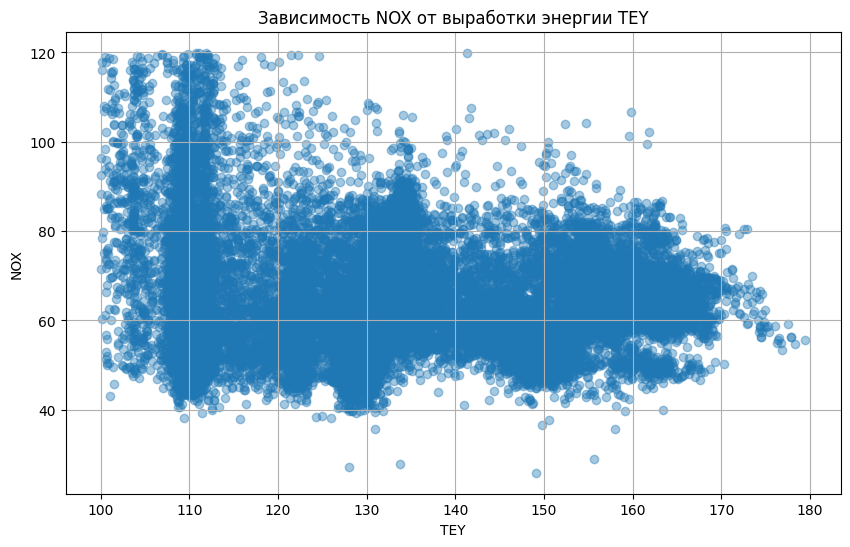

In [50]:
for target in ['CO', 'NOX']:
    plt.figure(figsize=(10, 6))
    plt.scatter(data['TEY'], data[target], alpha=0.4)
    plt.xlabel('TEY')
    plt.ylabel(target)
    plt.title(f'Зависимость {target} от выработки энергии TEY')
    plt.grid()
    plt.show()

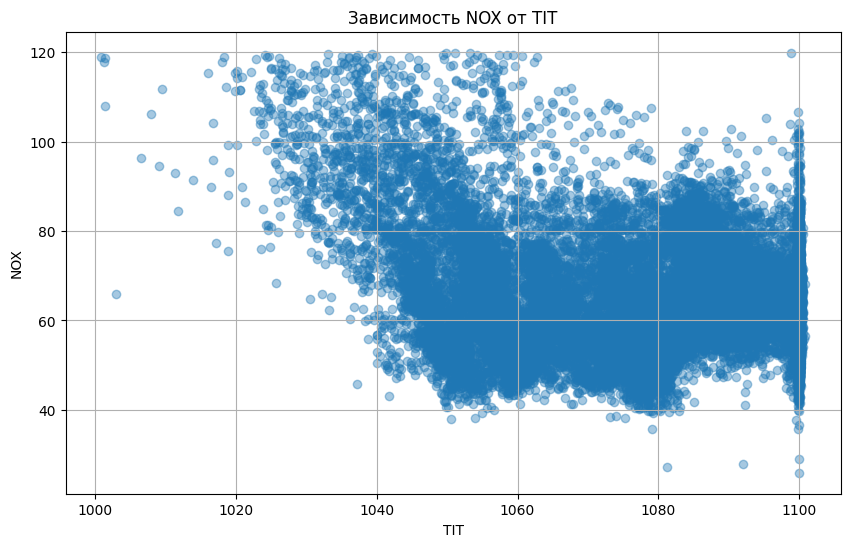

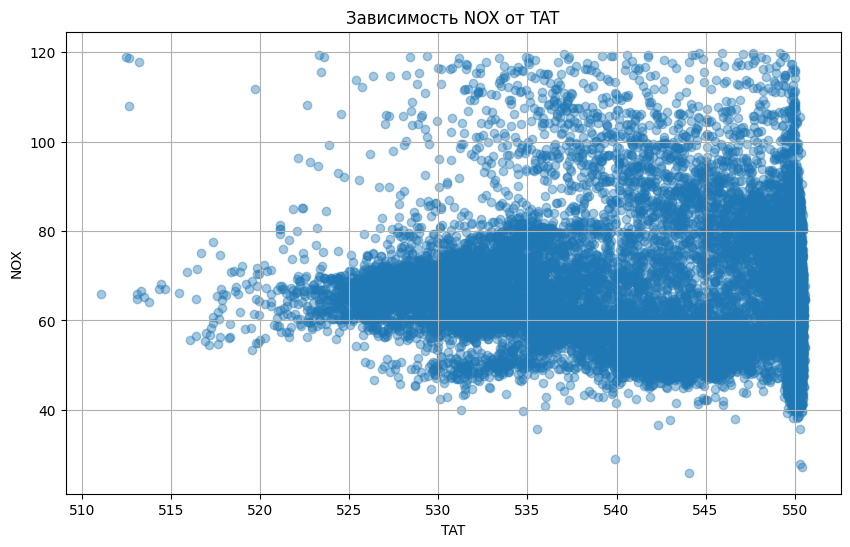

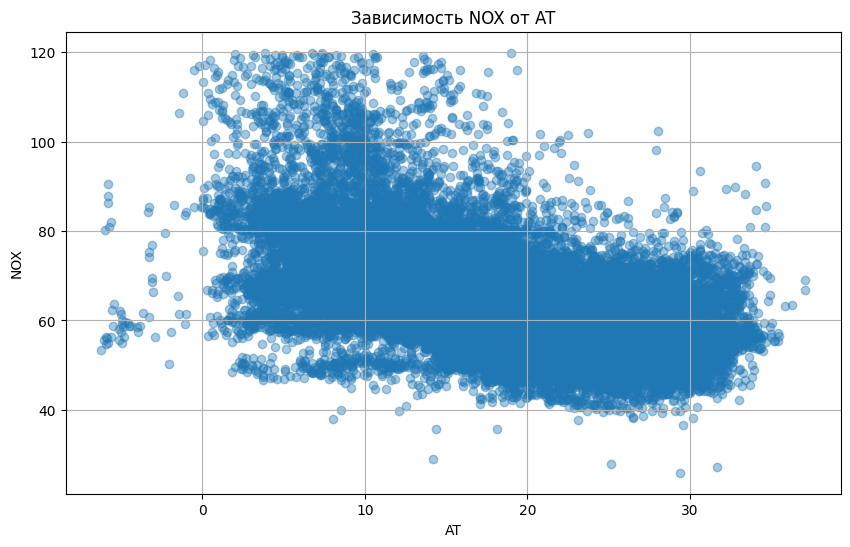

In [52]:
for feature in ['TIT', 'TAT', 'AT']:
    plt.figure(figsize=(10, 6))
    plt.scatter(data[feature], data['NOX'], alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel('NOX')
    plt.title(f'Зависимость NOX от {feature}')
    plt.grid()
    plt.show()

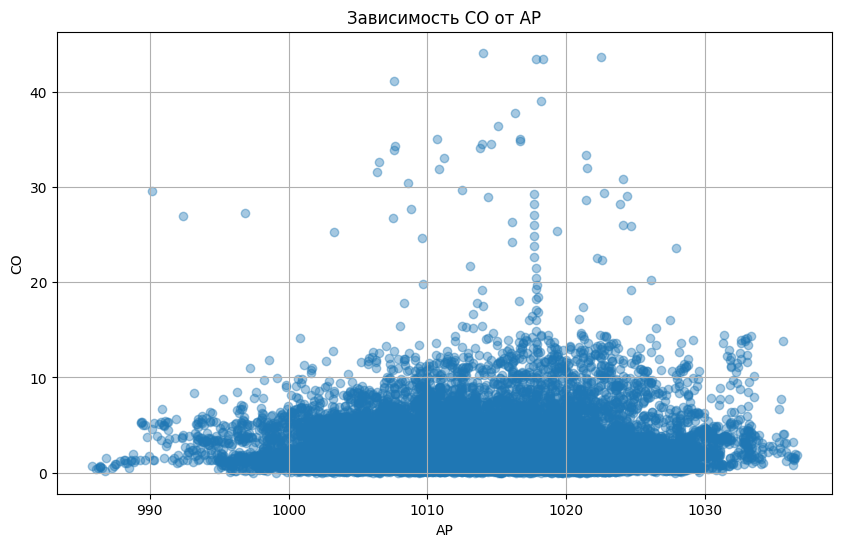

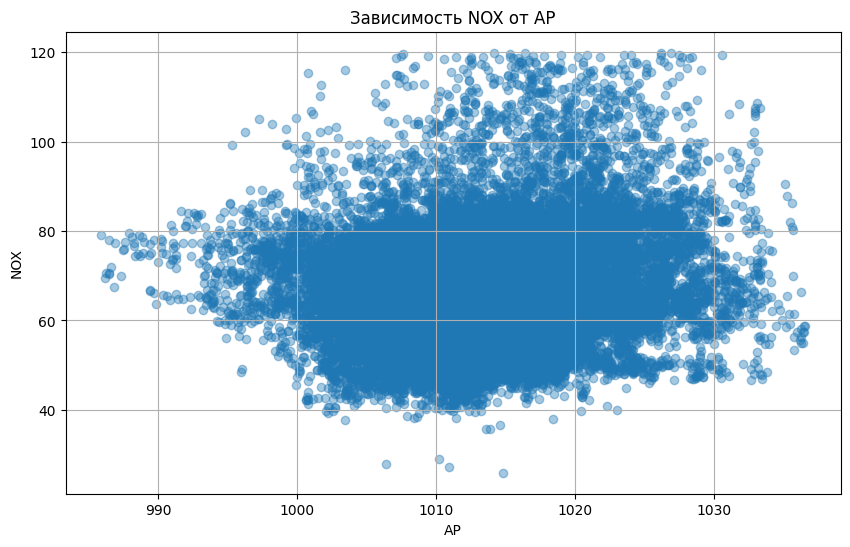

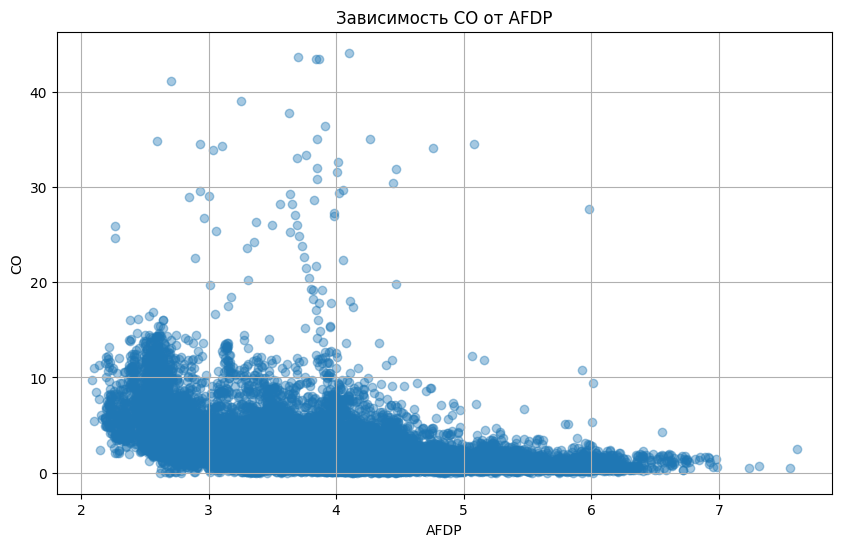

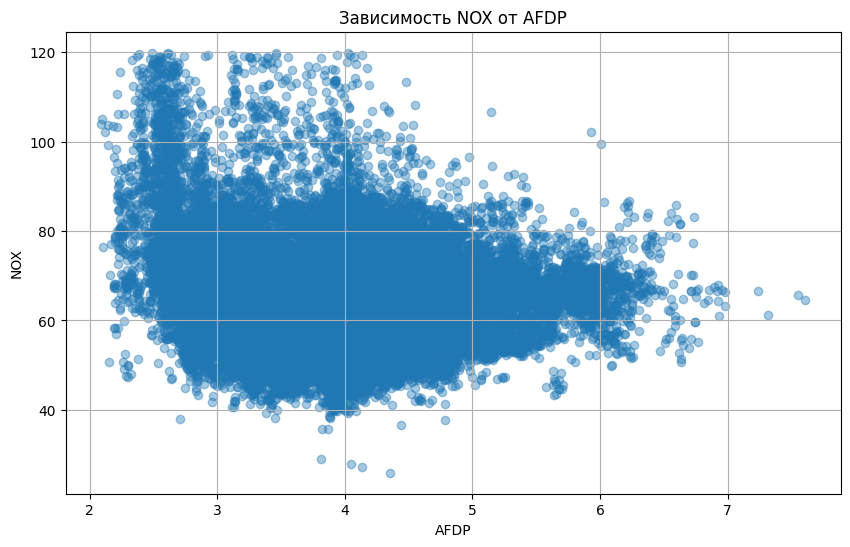

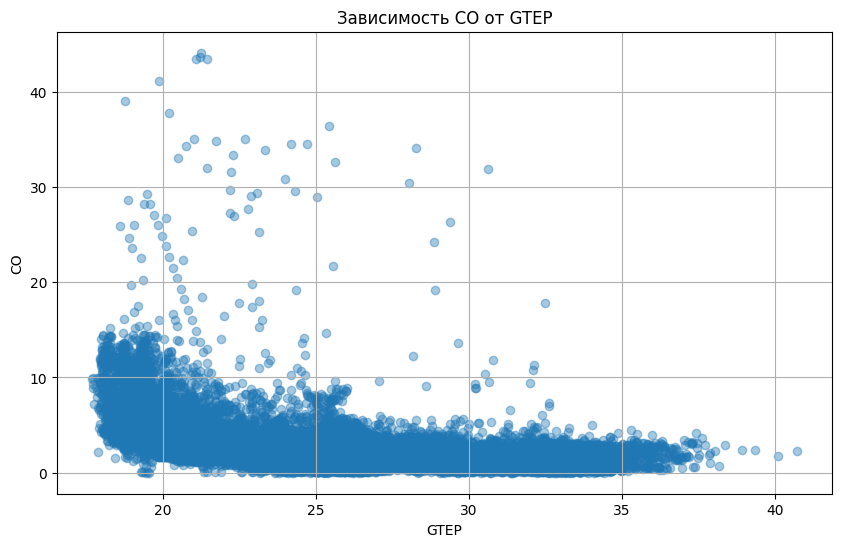

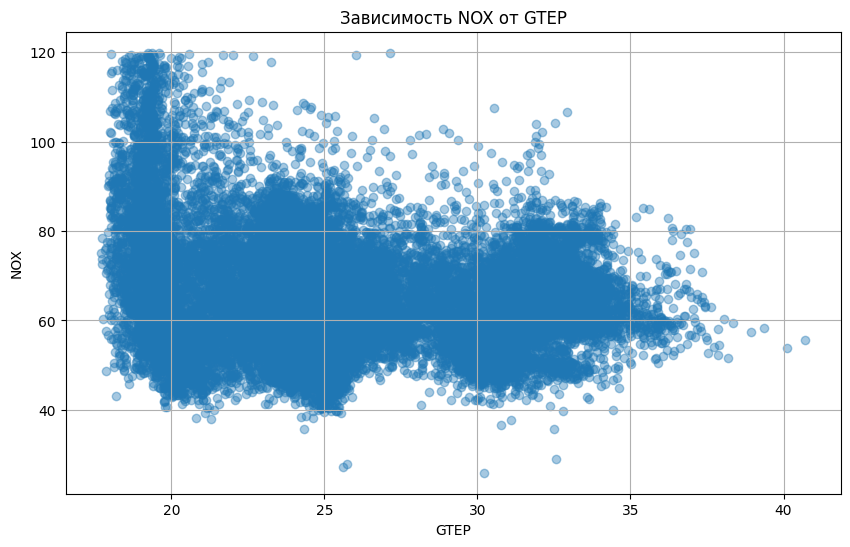

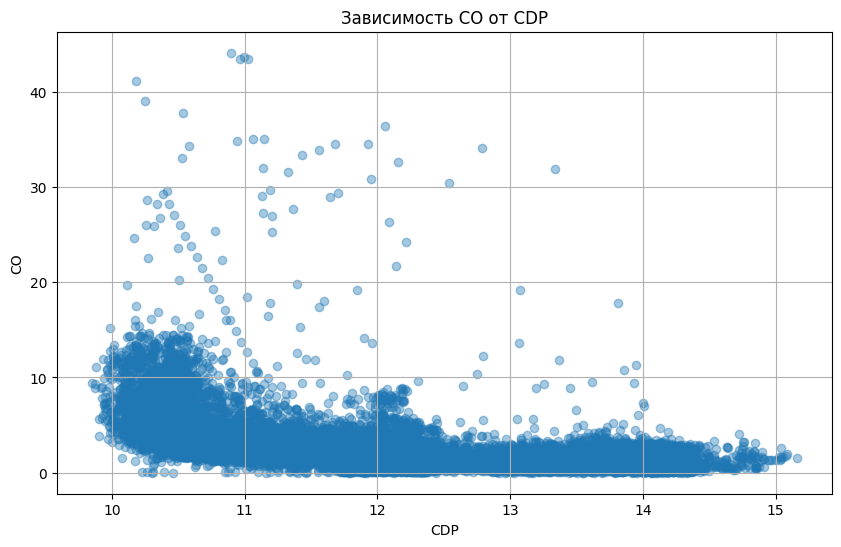

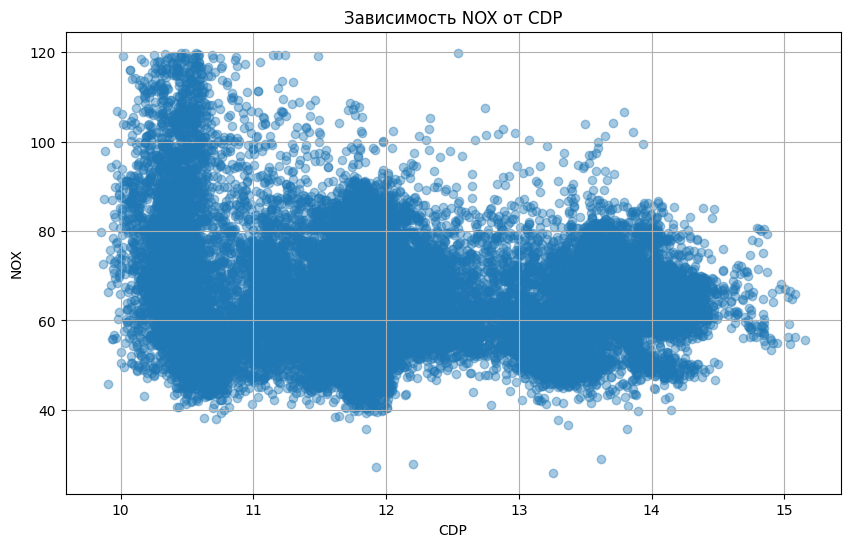

In [53]:
pressure_cols = ['AP', 'AFDP', 'GTEP', 'CDP']

for feature in pressure_cols:
    for target in ['CO', 'NOX']:
        plt.figure(figsize=(10, 6))
        plt.scatter(data[feature], data[target], alpha=0.4)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'Зависимость {target} от {feature}')
        plt.grid()
        plt.show()

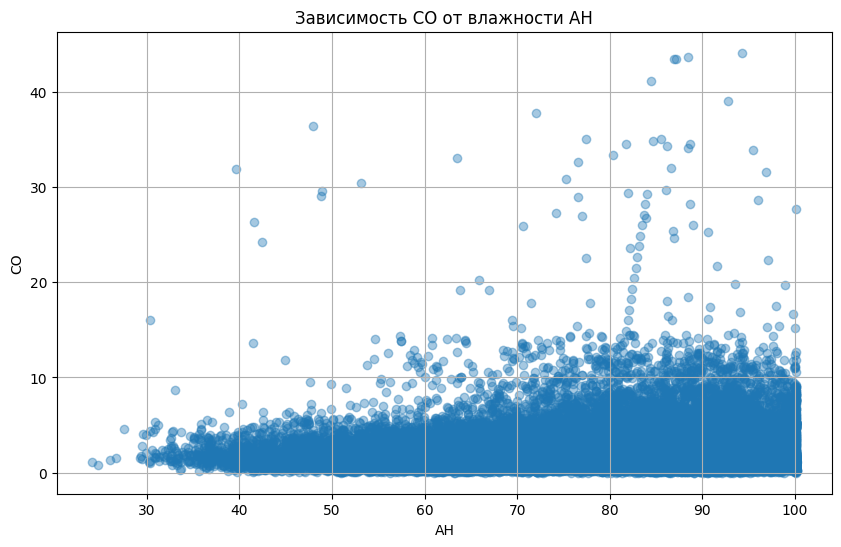

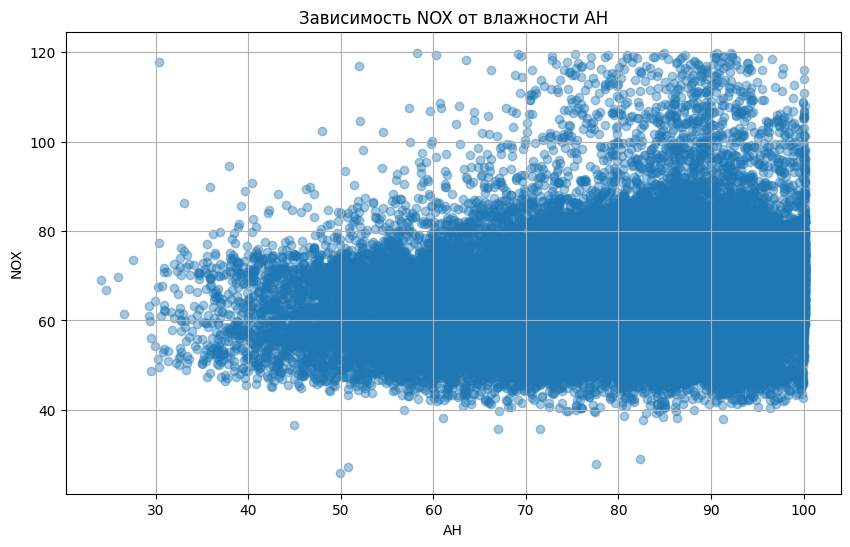

In [54]:
for target in ['CO', 'NOX']:
    plt.figure(figsize=(10, 6))
    plt.scatter(data['AH'], data[target], alpha=0.4)
    plt.xlabel('AH')
    plt.ylabel(target)
    plt.title(f'Зависимость {target} от влажности AH')
    plt.grid()
    plt.show()

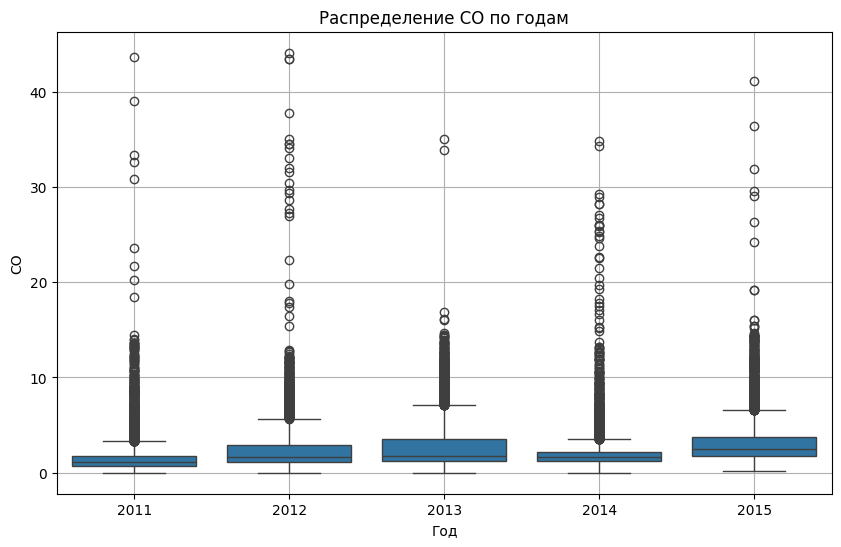

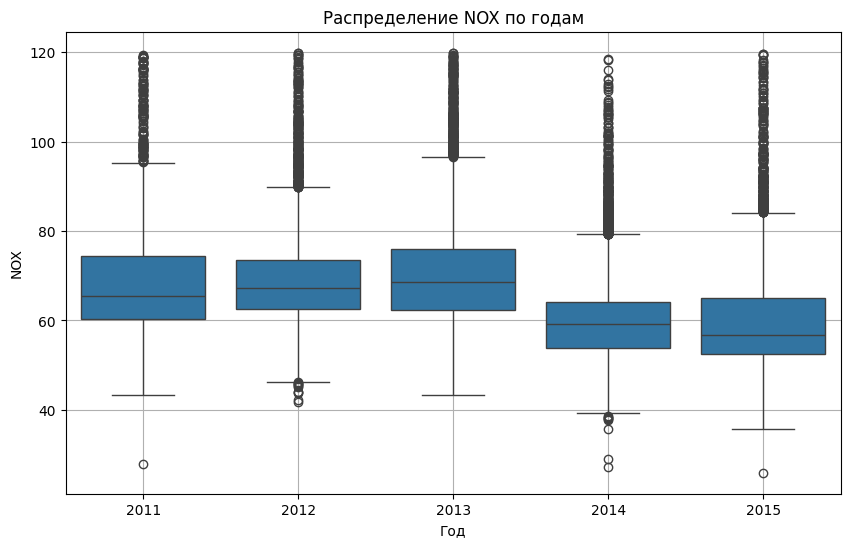

In [55]:
for target in ['CO', 'NOX']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x='year', y=target)
    plt.title(f'Распределение {target} по годам')
    plt.xlabel('Год')
    plt.ylabel(target)
    plt.grid()
    plt.show()

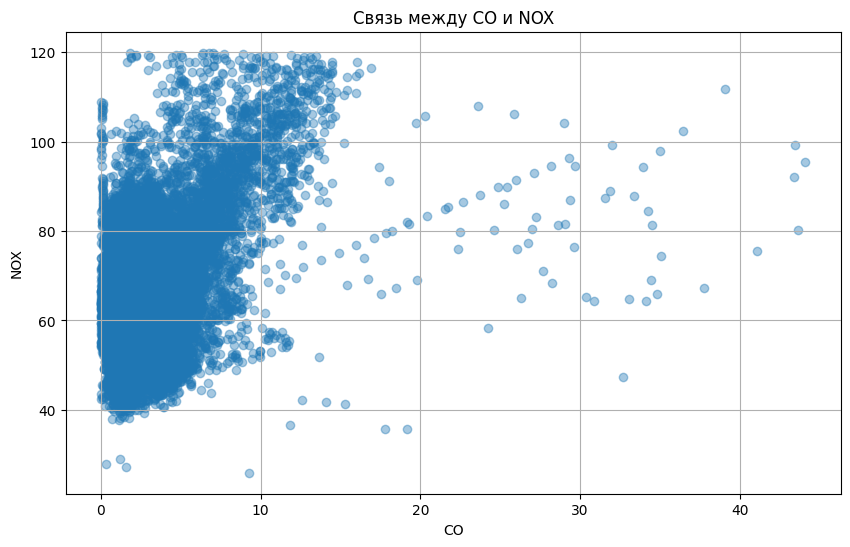

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(data['CO'], data['NOX'], alpha=0.4)
plt.xlabel('CO')
plt.ylabel('NOX')
plt.title('Связь между CO и NOX')
plt.grid()
plt.show()

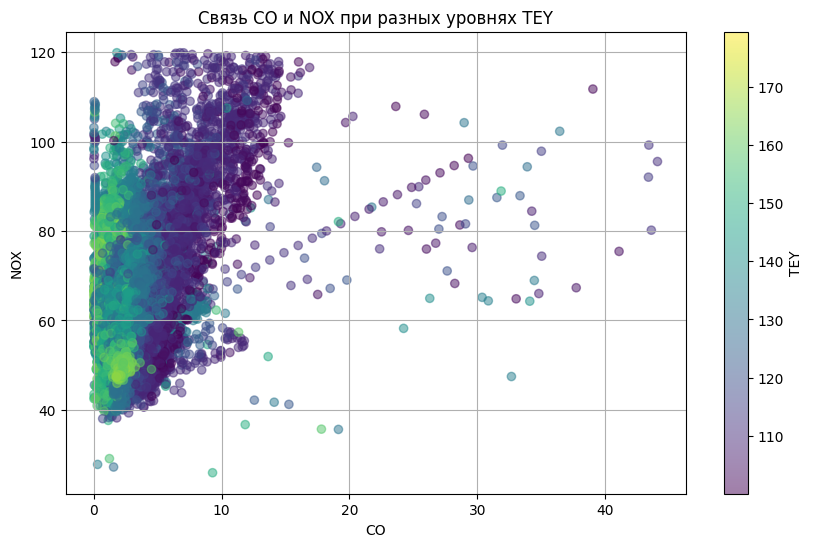

In [57]:
plt.figure(figsize=(10, 6))
plt.scatter(data['CO'], data['NOX'], c=data['TEY'], alpha=0.5)
plt.colorbar(label='TEY')
plt.xlabel('CO')
plt.ylabel('NOX')
plt.title('Связь CO и NOX при разных уровнях TEY')
plt.grid()
plt.show()